In [1]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import torch #modelin sinir ağı bu kütüphane üzerinden çalışacak
import cv2
from transformers import AutoProcessor, AutoModelForMultimodalLM
#Processor image i modelin anlayabileceği sayısal verilere(çok boyutlu sayısal diziler) çevirir
#AutoModelForMultimodalLM → MiniCPM-V modelini yükler config dosyasına göre modeli yükler
#AutoProcessor            → Görsel + metni modele hazırlar

c:\Users\durak\miniconda3\envs\minicpm46_clean\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#modelin ve processorun ortama yüklenmesi 
MODEL_ID = "openbmb/MiniCPM-V-4.6-BNB"

processor = AutoProcessor.from_pretrained(MODEL_ID) #Sadece görsel ve metni ileride nasıl hazırlayacağını bilen processor nesnesini oluşturuyor.
model = AutoModelForMultimodalLM.from_pretrained(
        MODEL_ID,
        device_map="auto" #modelin nerede çalıştırılacağı otomatik belirlenecek (CPU veya GPU)
    )
model.eval() #eğitim değil de inference modunda çalıştırılacak. Katmanların çalışma davranışını inference'a uygun hale getirir.

W0830 13:17:06.135000 21128 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 779/779 [00:00<00:00, 1149.88it/s]


MiniCPMV4_6ForConditionalGeneration(
  (model): MiniCPMV4_6Model(
    (vision_tower): MiniCPMV4_6VisionModel(
      (embeddings): MiniCPMV4_6VisionEmbeddings(
        (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
        (position_embedding): Embedding(4900, 1152)
      )
      (encoder): MiniCPMV4_6VisionEncoder(
        (layers): ModuleList(
          (0-26): 27 x MiniCPMV4_6VisionEncoderLayer(
            (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
            (self_attn): MiniCPMV4_6VisionAttention(
              (k_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
              (v_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
              (q_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
              (out_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
            )
            (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affin

In [3]:
#image in yüklenmesi
IMAGE_PATH = Path("test_pictures\catt.jpg")

image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise ValueError(f"Image not found at {IMAGE_PATH}")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB) #renk kanallarını değiştiriyoruz

In [ ]:
#chat modeli için inputu belirli bir konuşma yapısına getirilmesi
def build_messages(image_rgb, question):
    return [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_rgb
                },
                {
                    "type": "text",
                    "text": question
                }   
            ]
        }
    ]

In [ ]:
#modelin çalıştırılması
def ask_model(processor, model, image_rgb, question):
    #mesajın oluşturulması
    messages = build_messages(
        image_rgb,
        question
    )

    try:
        #mesajın processor a verilmesi ve sonucunda inputun artık modelin anlayacağı bir formata dönüştürülmesi
        inputs = processor.apply_chat_template(
            messages,
            tokenize=True, #girdileri tokenlara çevir
            add_generation_prompt=True, #özel tokenleri ekle
            return_dict=True, #girdileri dictionary formatında döndür
            return_tensors="pt", #çıktının tensor formatında olmasını sağla
        )

        inputs = inputs.to(model.device)

        #modelin cevap üretmesi
        with torch.inference_mode(): #inference modunda olduğumuz için gradient hesaplarını kapatıyor
            outputs = model.generate(
                **inputs,
                max_new_tokens=100, #cevabın uzunluğu 100 token ile sınırlandırılıyor
            )

        generated_tokens = outputs[:, inputs["input_ids"].shape[1]:] #model çıktı üretirken çıkışın başında inputu da eklediği için onu kesip sadece modelin ürettiği kısmı alıyoruz
        #burada inputs["input_ids"] kısmı girdilerin dictionarysindeki girdi değerleirni alır
        #.shade[1] ile de tensorün boyutunu gösterir
        # : ile de tensör boyutu kadar olan kısımdaki tensörleri keser.

        #çıktı oluşturulurken girdinin hemen #modelin cevap üretmesi
        #arkasına yeni tokenler ekleniyor o yüzden cevabı oluşturuken promptu silmek gerekli

        # Modelin ürettiği cevabı token ID'lerinden string'e çevirme
        response = processor.batch_decode(
            generated_tokens,
            skip_special_tokens=True,  # <eos>, <pad>, <assistant> gibi özel tokenları gösterme
        )[0]  # Batch içindeki ilk cevabı al tek görsel tek soru olduğu için

        return response.strip()

    except Exception as error:
        print("Model error:", error)
        return ""

In [7]:
#çıktıdan koordinatların çıkarılması
def parse_bbox(response):

    if not response:
        return None

    match = re.search(
        r"\[\s*"
        r"(\d+(?:\.\d+)?)\s*,\s*"
        r"(\d+(?:\.\d+)?)\s*,\s*"
        r"(\d+(?:\.\d+)?)\s*,\s*"
        r"(\d+(?:\.\d+)?)\s*\]",
        response
    )

    if match is None:
        return None

    return [
        float(value)
        for value in match.groups()
    ]

In [ ]:
#göreli konumu piksele çevirmek
def scale_box_to_pixels(box, width, height):

        x1, y1, x2, y2 = box

        x1 = int(x1 * width)
        y1 = int(y1 * height)
        x2 = int(x2 * width)
        y2 = int(y2 * height)

        return x1, y1, x2, y2 

In [ ]:
#piksel koordinatalarına göre bbox çizimi
def draw_bbox(image, box, label="object"):

    if box is None:
        return image.copy()

    height, width = image.shape[:2]

    x1, y1, x2, y2 = scale_box_to_pixels(
        box,
        width,
        height
    )

    # Koordinatlar geçerli mi?
    if x1 >= x2 or y1 >= y2:
        print("Invalid bounding box.")
        return image.copy()

    output_image = image.copy()

    cv2.rectangle(
        output_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        output_image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    return output_image

In [10]:
#modelin oluşturduğu resmi rgb ye çevirme ve yazdırma
def show_bbox_coordinates(box, image_bgr, label="object"):

    result_image = draw_bbox(
        image_bgr,
        box,
        label
    )

    result_image_rgb = cv2.cvtColor(
        result_image,
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(result_image_rgb)
    plt.axis("off")
    plt.show()

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Modelin ham cevabı:
The pixel bbox coordinates for the cats are approximately [0.27, 0.2, 0.47, 0.85]. This region captures the cat, which is sitting and facing the camera.

Model bbox coordinates:
[0.27, 0.2, 0.47, 0.85]


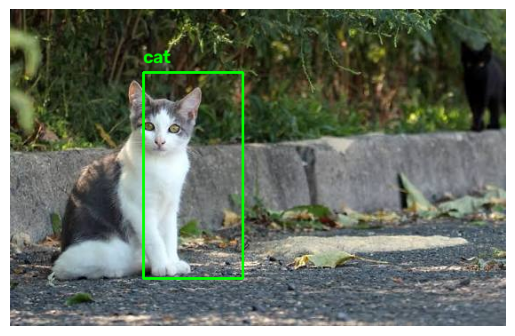

In [13]:
# %%
user_question = "What is the pixel bbox coordinates of the cats?"

question = user_question

response = ask_model(
    processor,
    model,
    image_rgb,
    question
)

print("Modelin ham cevabı:")
print(response)


box = parse_bbox(response)

if box is not None:

    print("\nModel bbox coordinates:")
    print(box)

    show_bbox_coordinates(
        box,
        image_bgr,
        "cat"
    )

else:

    print("\nModel geçerli bir bbox döndürmedi.")